# Demo 3 — Locally every smooth transformation is a matrix

Take the parrot bitmap and apply the nonlinear coordinate transformation

$$
\mathbf f(x,y)=
\begin{bmatrix}
x+a\sin(ky)\\
y+b\sin(kx)
\end{bmatrix}.
$$

The global warp is visibly nonlinear. On a sufficiently small region around $\mathbf x_0$, however, it is indistinguishable from the affine map

$$
\mathbf f(\mathbf x_0)
+J_{\mathbf f}(\mathbf x_0)(\mathbf x-\mathbf x_0).
$$

This is the geometric meaning of the derivative:

$$
\boxed{\text{calculus}+\text{linear algebra}=\text{local geometry}}
$$

In [1]:
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from matplotlib.patches import Rectangle
from PIL import Image
from scipy.ndimage import map_coordinates

plt.rcParams.update({"font.size": 13, "figure.dpi": 120})

## The bitmap and its coordinate system

We use ordinary Cartesian coordinates, with the origin at the center of the image and equal physical scale in the $x$ and $y$ directions.

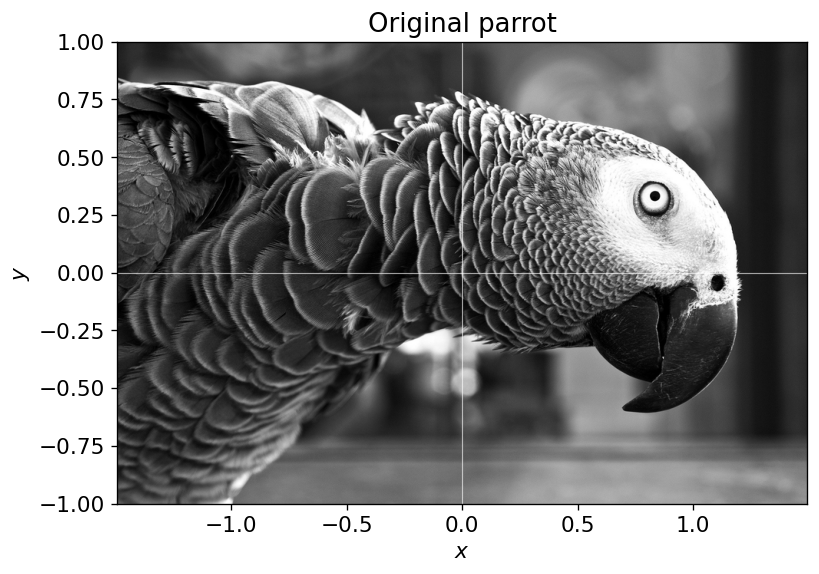

In [2]:
image_candidates = [Path("parrot.jpg"), Path("notebooks/parrot.jpg")]
image_path = next((path for path in image_candidates if path.exists()), None)
if image_path is None:
    raise FileNotFoundError("Could not find parrot.jpg")

parrot_image = Image.open(image_path).convert("RGB")
max_width = 900
if parrot_image.width > max_width:
    scale = max_width / parrot_image.width
    resized_shape = (max_width, round(scale * parrot_image.height))
    parrot_image = parrot_image.resize(resized_shape, Image.Resampling.LANCZOS)

image = np.asarray(parrot_image, dtype=float) / 255.0
image_height, image_width = image.shape[:2]
x_limit = image_width / image_height
y_limit = 1.0
image_extent = (-x_limit, x_limit, -y_limit, y_limit)

fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(image, extent=image_extent, origin="upper")
ax.axhline(0, color="white", lw=0.7, alpha=0.6)
ax.axvline(0, color="white", lw=0.7, alpha=0.6)
ax.set(xlabel="$x$", ylabel="$y$", title="Original parrot")
ax.set_aspect("equal")
plt.show()

## A nonlinear transformation

For this map, the Jacobian is

$$
J_{\mathbf f}(x,y)=
\begin{bmatrix}
1 & ak\cos(ky)\\
bk\cos(kx) & 1
\end{bmatrix}.
$$

The off-diagonal entries describe local shear: horizontal position responds to $y$, and vertical position responds to $x$.

In [3]:
a = 0.28
b = 0.22
k = 3.0

default_x0 = 0.86
default_y0 = 0.34
default_half_width = 0.16


def transform(x, y):
    """Apply the nonlinear coordinate transformation."""
    return x + a * np.sin(k * y), y + b * np.sin(k * x)


def jacobian(x, y):
    """Return the 2 x 2 Jacobian matrix at (x, y)."""
    return np.array(
        [
            [1.0, a * k * np.cos(k * y)],
            [b * k * np.cos(k * x), 1.0],
        ]
    )


def inverse_transform(u, v, iterations=18):
    """Invert the warp by fixed-point iteration on an output grid."""
    x = np.array(u, copy=True)
    y = np.array(v, copy=True)
    for _ in range(iterations):
        x = u - a * np.sin(k * y)
        y = v - b * np.sin(k * x)
    return x, y


def sample_image(x, y):
    """Sample RGB values at Cartesian image coordinates."""
    row = (y_limit - y) * (image_height - 1) / (2 * y_limit)
    column = (x + x_limit) * (image_width - 1) / (2 * x_limit)
    sampled = np.empty(x.shape + (3,), dtype=float)
    for channel in range(3):
        sampled[..., channel] = map_coordinates(
            image[..., channel],
            [row, column],
            order=3,
            mode="constant",
            cval=1.0,
        )
    return np.clip(sampled, 0.0, 1.0)


def square_boundary(x0, y0, half_width, points_per_side=120):
    """Return a closed, counterclockwise square boundary."""
    low_x, high_x = x0 - half_width, x0 + half_width
    low_y, high_y = y0 - half_width, y0 + half_width
    t = np.linspace(0.0, 1.0, points_per_side, endpoint=False)
    x = np.concatenate(
        [
            low_x + 2 * half_width * t,
            np.full_like(t, high_x),
            high_x - 2 * half_width * t,
            np.full_like(t, low_x),
            [low_x],
        ]
    )
    y = np.concatenate(
        [
            np.full_like(t, low_y),
            low_y + 2 * half_width * t,
            np.full_like(t, high_y),
            high_y - 2 * half_width * t,
            [low_y],
        ]
    )
    return x, y

## The global warp

The regular grid bends across the transformed image. The highlighted square surrounds the parrot's eye; its transformed boundary is no longer exactly a parallelogram.

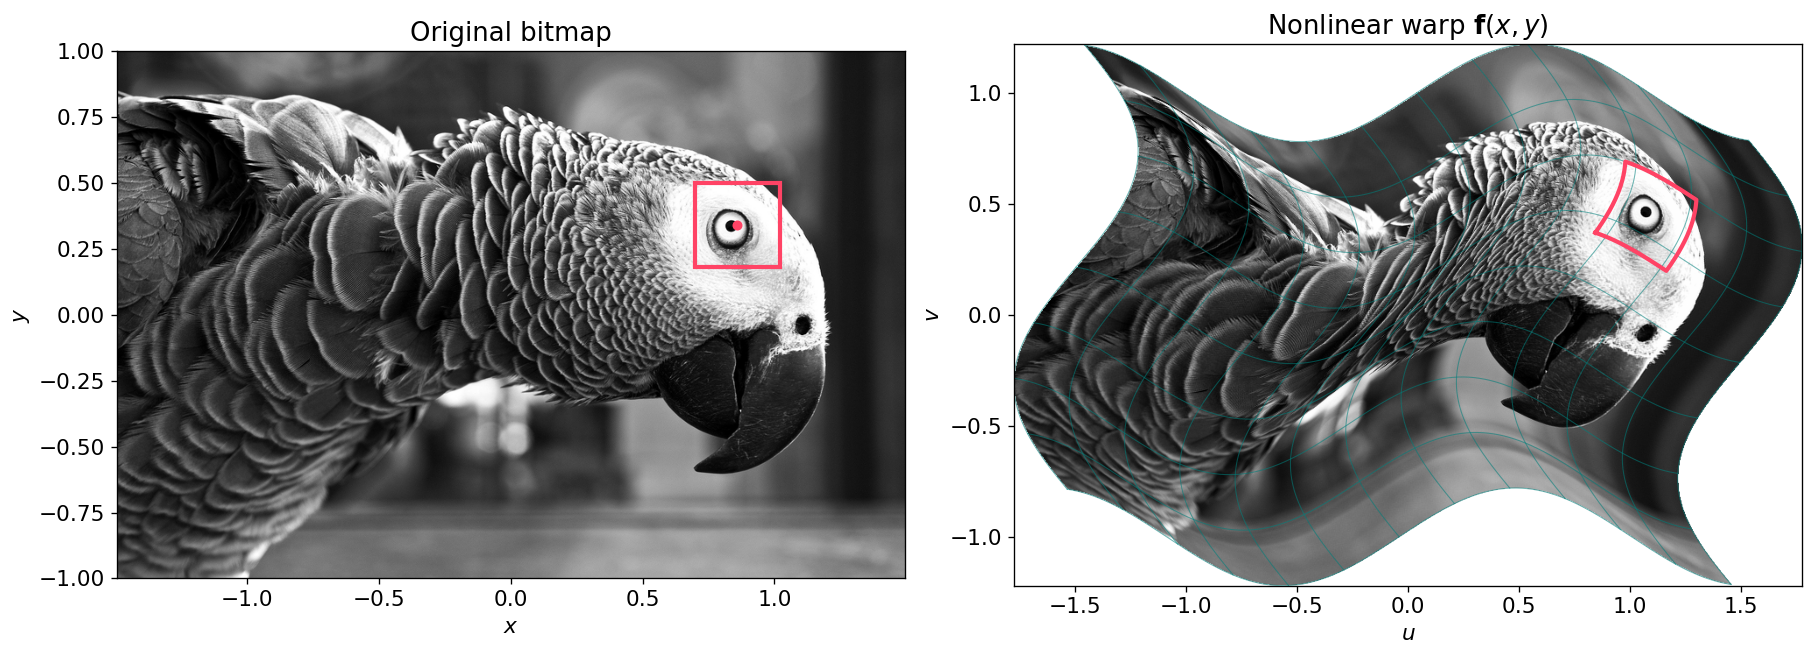

In [4]:
output_x_min = -x_limit - abs(a)
output_x_max = x_limit + abs(a)
output_y_min = -y_limit - abs(b)
output_y_max = y_limit + abs(b)
output_height = 620
output_width = round(
    output_height
    * (output_x_max - output_x_min)
    / (output_y_max - output_y_min)
)

output_x = np.linspace(output_x_min, output_x_max, output_width)
output_y = np.linspace(output_y_max, output_y_min, output_height)
output_X, output_Y = np.meshgrid(output_x, output_y)
source_X, source_Y = inverse_transform(output_X, output_Y)
warped_image = sample_image(source_X, source_Y)

square_x, square_y = square_boundary(
    default_x0, default_y0, default_half_width
)
warped_square_x, warped_square_y = transform(square_x, square_y)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), layout="constrained")

axes[0].imshow(image, extent=image_extent, origin="upper")
axes[0].add_patch(
    Rectangle(
        (default_x0 - default_half_width, default_y0 - default_half_width),
        2 * default_half_width,
        2 * default_half_width,
        fill=False,
        edgecolor="#ff4365",
        linewidth=2.5,
    )
)
axes[0].plot(default_x0, default_y0, "o", color="#ff4365", ms=5)
axes[0].set(title="Original bitmap", xlabel="$x$", ylabel="$y$")

axes[1].imshow(
    warped_image,
    extent=(output_x_min, output_x_max, output_y_min, output_y_max),
    origin="upper",
)
grid_color = "#007f7b"
line_parameter = np.linspace(-1.0, 1.0, 500)
for fixed_x in np.linspace(-x_limit, x_limit, 13):
    grid_y = y_limit * line_parameter
    grid_x = np.full_like(grid_y, fixed_x)
    warped_x, warped_y = transform(grid_x, grid_y)
    axes[1].plot(warped_x, warped_y, color=grid_color, lw=0.65, alpha=0.55)
for fixed_y in np.linspace(-y_limit, y_limit, 9):
    grid_x = x_limit * line_parameter
    grid_y = np.full_like(grid_x, fixed_y)
    warped_x, warped_y = transform(grid_x, grid_y)
    axes[1].plot(warped_x, warped_y, color=grid_color, lw=0.65, alpha=0.55)
axes[1].plot(
    warped_square_x, warped_square_y, color="#ff4365", lw=2.5
)
axes[1].set(title=r"Nonlinear warp $\mathbf{f}(x,y)$", xlabel="$u$", ylabel="$v$")

for ax in axes:
    ax.set_aspect("equal")
plt.show()

## Zoom in: the Jacobian takes over

At $\mathbf x_0=(x_0,y_0)$, define

$$
L_{\mathbf x_0}(\mathbf x)
=\mathbf f(\mathbf x_0)
+J_{\mathbf f}(\mathbf x_0)(\mathbf x-\mathbf x_0).
$$

The next visualization maps the **same pixels** in two ways. Reduce the patch width and watch the nonlinear image converge to its affine, matrix-generated approximation.

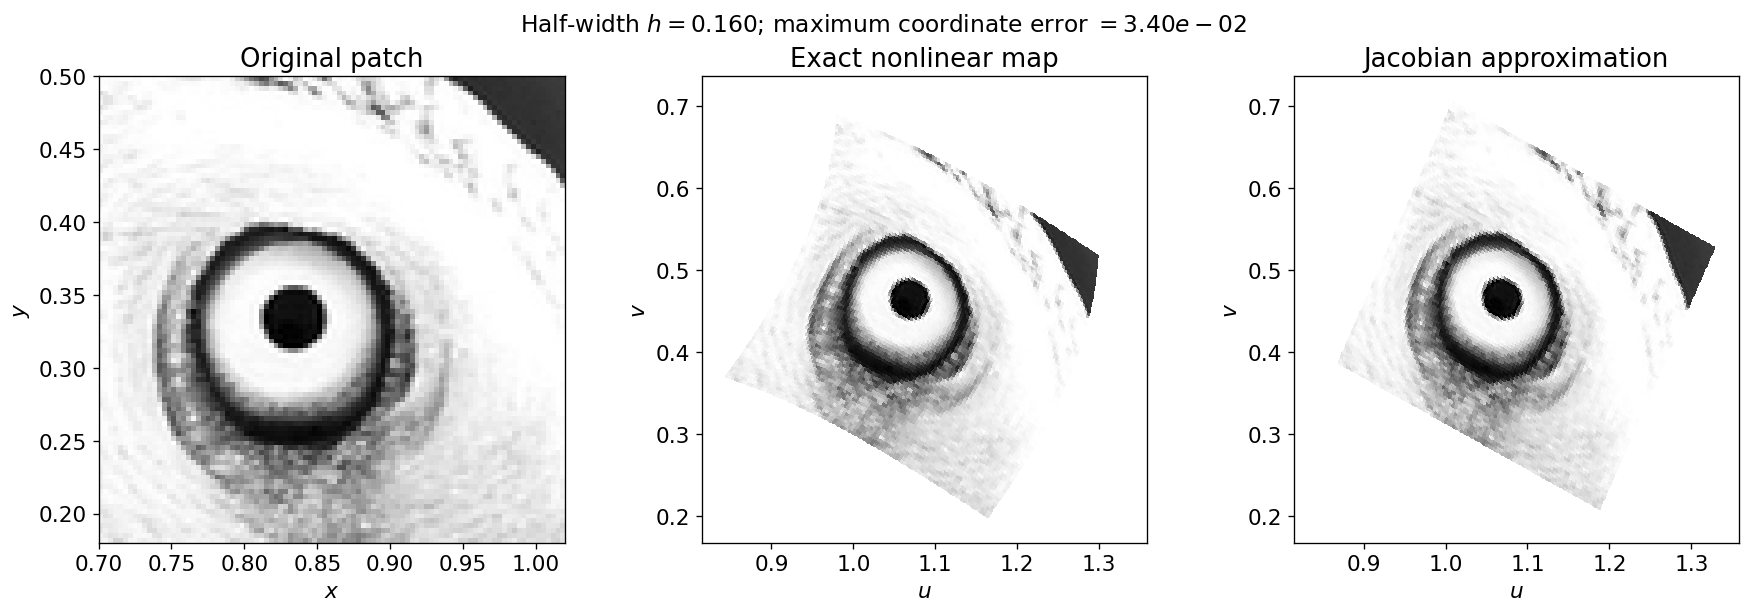

In [5]:
def show_local_comparison(x0, y0, half_width):
    """Compare the exact and Jacobian transformations of one image patch."""
    patch_points = 96
    x_edges = np.linspace(x0 - half_width, x0 + half_width, patch_points + 1)
    y_edges = np.linspace(y0 - half_width, y0 + half_width, patch_points + 1)
    X_edges, Y_edges = np.meshgrid(x_edges, y_edges)

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    X_centers, Y_centers = np.meshgrid(x_centers, y_centers)
    patch = sample_image(X_centers, Y_centers)

    exact_X, exact_Y = transform(X_edges, Y_edges)

    center_image = np.array(transform(x0, y0))
    center_offsets = np.stack((X_edges - x0, Y_edges - y0), axis=0)
    linear_offsets = np.einsum("ij,jmn->imn", jacobian(x0, y0), center_offsets)
    linear_X = center_image[0] + linear_offsets[0]
    linear_Y = center_image[1] + linear_offsets[1]

    pointwise_error = np.hypot(exact_X - linear_X, exact_Y - linear_Y)
    max_error = np.max(pointwise_error)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")
    axes[0].pcolormesh(
        X_edges, Y_edges, patch, shading="flat", rasterized=True
    )
    axes[0].set(title="Original patch", xlabel="$x$", ylabel="$y$")

    axes[1].pcolormesh(
        exact_X, exact_Y, patch, shading="flat", rasterized=True
    )
    axes[1].set(title="Exact nonlinear map", xlabel="$u$", ylabel="$v$")

    axes[2].pcolormesh(
        linear_X, linear_Y, patch, shading="flat", rasterized=True
    )
    axes[2].set(title="Jacobian approximation", xlabel="$u$", ylabel="$v$")

    transformed_x = np.concatenate((exact_X.ravel(), linear_X.ravel()))
    transformed_y = np.concatenate((exact_Y.ravel(), linear_Y.ravel()))
    x_padding = 0.06 * np.ptp(transformed_x)
    y_padding = 0.06 * np.ptp(transformed_y)
    common_xlim = (transformed_x.min() - x_padding, transformed_x.max() + x_padding)
    common_ylim = (transformed_y.min() - y_padding, transformed_y.max() + y_padding)
    for ax in axes[1:]:
        ax.set_xlim(common_xlim)
        ax.set_ylim(common_ylim)

    for ax in axes:
        ax.set_aspect("equal")
        ax.ticklabel_format(style="plain", useOffset=False)

    fig.suptitle(
        rf"Half-width $h={half_width:.3f}$; maximum coordinate error $={max_error:.2e}$",
        fontsize=14,
    )
    plt.show()


show_local_comparison(default_x0, default_y0, default_half_width)

## Interactive microscope

Move the center to select a different part of the parrot. The logarithmic size slider makes it easy to shrink the square by orders of magnitude.

In [6]:
x0_slider = widgets.FloatSlider(
    value=default_x0,
    min=-x_limit + 0.32,
    max=x_limit - 0.32,
    step=0.02,
    description="$x_0$",
    continuous_update=False,
)
y0_slider = widgets.FloatSlider(
    value=default_y0,
    min=-0.68,
    max=0.68,
    step=0.02,
    description="$y_0$",
    continuous_update=False,
)
size_slider = widgets.FloatLogSlider(
    value=default_half_width,
    base=10,
    min=-2.0,
    max=np.log10(0.30),
    step=0.05,
    description="half-width",
    readout_format=".3f",
    continuous_update=False,
)

local_output = widgets.interactive_output(
    show_local_comparison,
    {"x0": x0_slider, "y0": y0_slider, "half_width": size_slider},
)
display(widgets.VBox([widgets.HBox([x0_slider, y0_slider, size_slider]), local_output]))

## What to notice

- Globally, $\mathbf f$ bends the coordinate grid and distorts the parrot. One matrix cannot describe the whole warp.
- Locally, the Jacobian $J_{\mathbf f}(\mathbf x_0)$ gives the translation, rotation, shear, and scale seen by a tiny image patch.
- For a smooth map, the neglected Taylor remainder is second order: the absolute discrepancy decreases like $O(h^2)$ as the patch half-width $h$ shrinks.

$$
\boxed{\text{The derivative is the best local matrix model.}}
$$